In [2]:
import pandas as pd 
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore
%matplotlib inline


data = 'Mall_Customers.csv'
df = pd.read_csv(data)
df.head(15)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   CustomerID               200 non-null    int64 
 1    Gender                  200 non-null    object
 2    Age                     200 non-null    int64 
 3    Annual Income (k$)      200 non-null    int64 
 4    Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.isnull().sum()

CustomerID                 0
 Gender                    0
 Age                       0
 Annual Income (k$)        0
 Spending Score (1-100)    0
dtype: int64

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.columns = df.columns.str.strip()
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [7]:
# масштабируем данные
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scal = scaler.fit_transform(X)

k = 1 and interia = 399.99999999999994
k = 2 and interia = 269.69101219276394
k = 3 and interia = 157.70400815035947
k = 4 and interia = 108.92131661364357
k = 5 and interia = 65.56840815571681


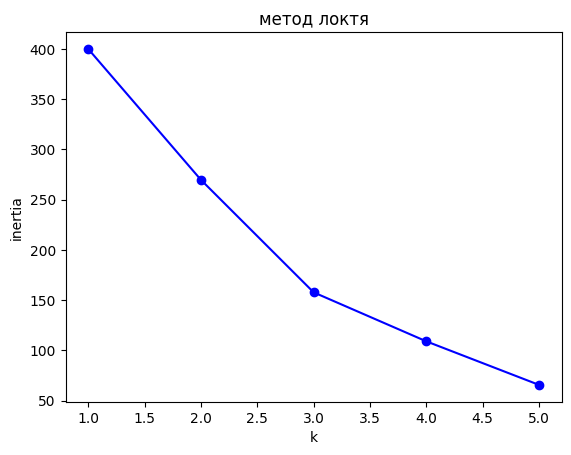

In [8]:
from sklearn.cluster import KMeans
# метод локтя
# сразу пишем диапазон чисел кластера
k_range = range(1, 6)
inertias = []
# рассчет значения K для inertias(суммы квадратов)
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(x_scal)
    inertias.append(kmeans.inertia_)
    print(f"k = {k} and interia = {kmeans.inertia_}")
# рисование гарфиков
plt.plot(range (1, 6), inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('inertia')
plt.title('метод локтя')
plt.show()

по методу локтя нужно брать К = 4 (но это не точное значение)

k = 2 and score = 0.3212707813918878
k = 3 and score = 0.46658474419000145
k = 4 and score = 0.4939069237513199
k = 5 and score = 0.5546571631111091
k = 6 and score = 0.5398800926790663


<function matplotlib.pyplot.show(close=None, block=None)>

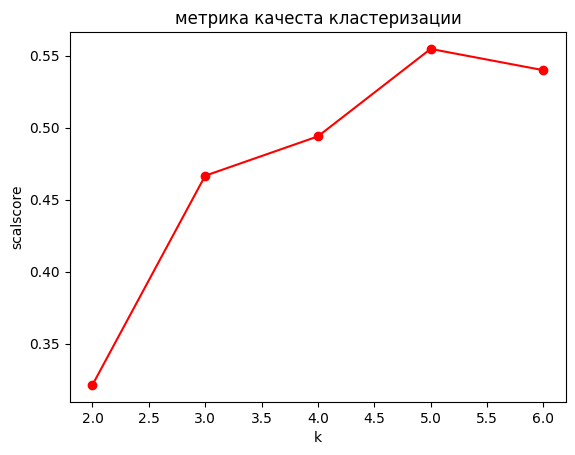

In [9]:
from sklearn.metrics import silhouette_score
sil_score = []
for k in range(2, 7):
    kmeans_sil = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans_sil.fit(x_scal)
    score = silhouette_score(x_scal, kmeans_sil.labels_)
    sil_score.append(score)
    print(f"k = {k} and score = {score}")

plt.plot(range(2, 7), sil_score, 'ro-')
plt.xlabel('k'); plt.ylabel('scalscore'); plt.title('метрика качеста кластеризации')
plt.show

по значению метрики берем занчение К = 5 (очень точно)

In [10]:
k_means = KMeans(n_clusters=5, n_init=10, random_state=42)
df["Cluster"] = k_means.fit_predict(x_scal)
print(df["Cluster"].sort_index())

0      4
1      2
2      4
3      2
4      4
      ..
195    1
196    3
197    1
198    3
199    1
Name: Cluster, Length: 200, dtype: int32


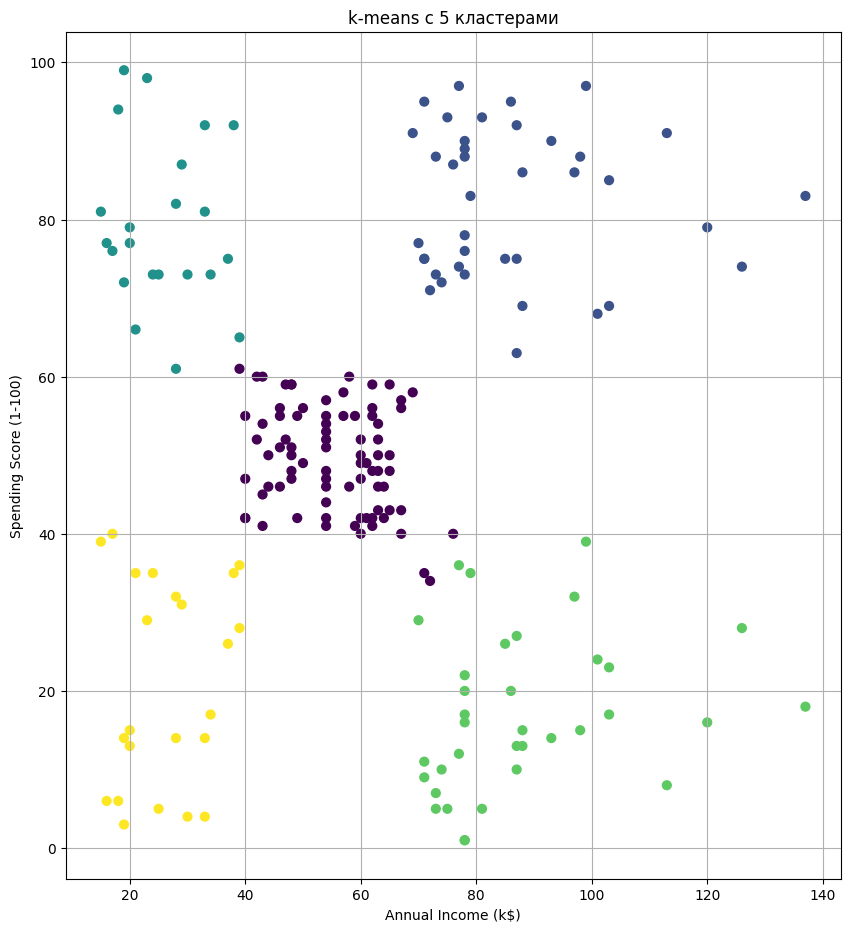

In [11]:
# отрисовка результата по доходу и скору
labels = kmeans.labels_
centers = kmeans.cluster_centers_
plt.figure(figsize=(10,11))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c = labels,
    cmap='viridis',
    s=40
)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('k-means c 5 кластерами')
plt.grid(True)


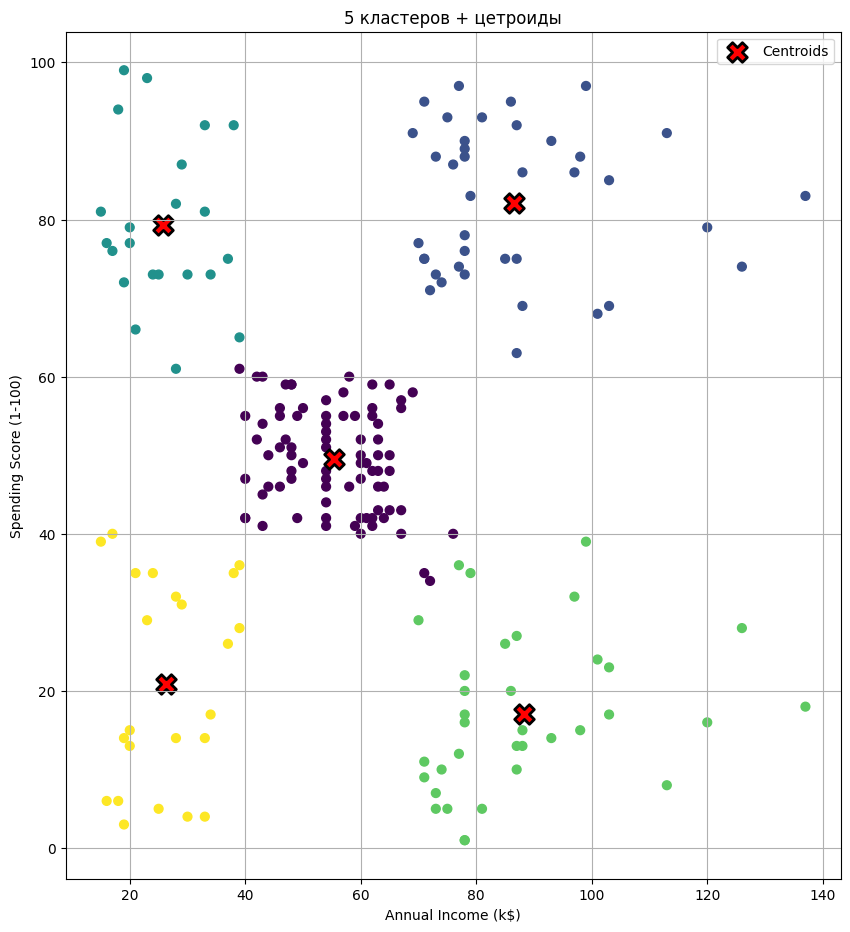

In [12]:
# та же диаграмма + центроиды
plt.figure(figsize=(10,11))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c = labels,
    cmap='viridis',
    s=40
)
centr_orig = scaler.inverse_transform(centers)
centers_income = centr_orig[:, 0]
centers_score = centr_orig[:, 1]
plt.scatter(
    centers_income,
    centers_score,
    c = 'red',
    s = 200,
    marker='X',
    edgecolors='black',
    linewidths=2,
    label = 'Centroids'
)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('5 кластеров + цетроиды')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
df['Cluster'] = k_means.labels_
cluster_stats = (
    df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
    .mean()
    .round(1)
    .sort_values(by='Age')
)
print(cluster_stats)

          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
2        25.3                25.7                    79.4
1        32.7                86.5                    82.1
3        41.1                88.2                    17.1
0        42.7                55.3                    49.5
4        45.2                26.3                    20.9


In [15]:
import joblib
joblib.dump(k_means, 'my_model.joblib')


['my_model.joblib']